# Mini Equations Experiment Report

This notebook reviews the curated experiments in `examples/mini_eqns/experiments/report`. The report directory now contains **13 baseline runs**, **9 guided runs**, and **9 step-by-step runs** over the 22-equation benchmark.

The notebook stays selective on purpose. Rather than repeating every raw table, it focuses on the comparisons that matter for the report draft: how reasoning effort changes each strategy, whether `mini` or `nano` are worth using, what the newly added `step_by_step` runs change in the overall picture, and where each model still tends to fail.


In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import HTML, SVG, display

for candidate in [Path.cwd(), *Path.cwd().parents]:
    report_dir = candidate / 'examples' / 'mini_eqns' / 'experiments' / 'report'
    if report_dir.exists():
        REPORT_DIR = report_dir
        break
else:
    raise FileNotFoundError('Could not locate examples/mini_eqns/experiments/report from the current working directory.')

if str(REPORT_DIR) not in sys.path:
    sys.path.insert(0, str(REPORT_DIR))

import report_utils as ru

paths = ru.find_report_paths(Path.cwd())
benchmarks = ru.load_benchmarks(paths.benchmark_file)
runs = ru.load_report_runs(paths.report_root)
inventory = ru.build_experiment_inventory(runs)
best_configs = ru.select_best_configs(inventory)
best_baseline_name = str(best_configs.loc[best_configs['family'] == 'baseline', 'experiment_name'].iloc[0])
best_guided_name = str(best_configs.loc[best_configs['family'] == 'guided', 'experiment_name'].iloc[0])
best_step_name = str(best_configs.loc[best_configs['family'] == 'step_by_step', 'experiment_name'].iloc[0])
step_advantage = ru.build_step_advantage_table(runs, benchmarks, best_baseline_name, best_guided_name, best_step_name)

pd.set_option('display.max_colwidth', 120)
display(HTML('''
<style>
.jp-RenderedMarkdown {
  max-width: 920px;
  margin: 0 auto;
  line-height: 1.55;
}
.jp-RenderedMarkdown h1 { font-size: 1.75rem; margin-top: 0.15rem; margin-bottom: 0.55rem; }
.jp-RenderedMarkdown h2 { font-size: 1.22rem; margin-top: 1.35rem; margin-bottom: 0.4rem; }
.jp-RenderedMarkdown h3 { font-size: 1.02rem; margin-top: 0.95rem; margin-bottom: 0.28rem; }
.jp-RenderedMarkdown p, .jp-RenderedMarkdown li { font-size: 0.97rem; }
.table-container, .strategy-wrap { max-width: 920px; margin: 0 auto; }
.report-simple-table, .strategy-matrix {
  border-collapse: collapse;
  width: 100%;
  font-size: 13px;
  margin: 0.35rem 0 0.8rem 0;
}
.report-simple-table th, .report-simple-table td, .strategy-matrix th, .strategy-matrix td {
  border-bottom: 1px solid #e5e7eb;
  padding: 8px 10px;
  text-align: left;
  vertical-align: middle;
}
.report-simple-table th, .strategy-matrix th {
  background: #f8fafc;
  font-weight: 600;
}
.strategy-matrix td.empty {
  color: #94a3b8;
  text-align: center;
}
.matrix-card {
  border-radius: 10px;
  padding: 10px 10px 8px 10px;
  min-width: 108px;
  box-shadow: inset 0 0 0 1px rgba(255,255,255,.45);
}
.matrix-card .solve { font-size: 16px; font-weight: 700; line-height: 1.1; }
.matrix-card .cost { font-size: 12px; margin-top: 4px; }
.matrix-card .label { font-size: 11px; margin-top: 6px; opacity: .82; }
</style>
'''))

## Methodology

All configuration metadata is recovered from `experiment.yaml`, while solved counts and cost come from `results_summary.csv`. The summary matrices below show solved equations out of 22, total run cost, and a short experiment label.

Two legacy baseline runs use reasoning effort `None`: `baseline_experiment_1` and `baseline_experiment_6`. That label is carried explicitly in this report rather than being treated as missing metadata. For the current step-by-step runs, the sketch planner is fixed at `gpt-5.4` with `medium` reasoning effort, so the visible variation comes from the step executor.


## Baseline

The baseline sweep still tells a clean story. A modest amount of forced reasoning helps standard `gpt-5.4`, but pushing reasoning harder stops paying off.

### Supported takeaways

- For standard `gpt-5.4`, `low` and `medium` tie at **19/22**, but `low` is the better choice because it costs **$1.1375** instead of **$1.4732**.
- More reasoning is not automatically better on this benchmark. `high` falls to **18/22**, `None` falls to **15/22**, and `xhigh` reaches only **17/22** while costing **$3.1657**.
- `xhigh` is therefore not worth pursuing for baseline here: compared with `low`, it costs about **$2.0281 more** and solves **2 fewer** equations.
- `gpt-5.4-mini` is dominated by standard `gpt-5.4` on the current baseline sweep. At `low`, the standard model solves **19/22** for **$1.1375**, while mini solves only **10/22** for **$2.8744**.
- `gpt-5.4-nano` is the stronger lightweight baseline contender. At `medium` and `high`, nano reaches **16/22** and **17/22**, while mini reaches only **14/22** and **10/22**. A cautious interpretation is that nano responds much better than mini to explicit reasoning effort on this short proof benchmark.


In [2]:
display(HTML(ru.render_strategy_matrix_html(inventory, 'baseline')))

Model,None,low,medium,high,xhigh
GPT-5.4,15 / 22$1.67B1,19 / 22$1.14B2,19 / 22$1.47B3,18 / 22$1.83B4,17 / 22$3.17B5
GPT-5.4 mini,11 / 22$2.95B6,10 / 22$2.87B7,14 / 22$3.39B8,10 / 22$3.96B9,—
GPT-5.4 nano,—,9 / 22$3.06B10,16 / 22$2.73B11,17 / 22$2.68B12,16 / 22$6.57B13


## Guided

Guided search remains competitive, but it does not create a better frontier than baseline on the current report runs.

### Supported takeaways

- On `gpt-5.4`, guided reaches **18/22**, **19/22**, and **19/22** at `low`, `medium`, and `high`. That is very close to baseline's **19/22**, **19/22**, and **18/22** at the same effort levels.
- That similarity comes with a clear premium. Relative to baseline, guided costs about **$0.5808** more at `low`, **$0.5336** more at `medium`, and **$0.8622** more at `high`.
- Higher reasoning effort in guided does not hurt solved count on `gpt-5.4`, but it still raises cost: `medium` and `high` both solve **19/22**, while `high` pays **$0.6866** more.
- Guided does not rescue `gpt-5.4-mini`. Solved count stays flat at **12/22** while cost rises from **$3.0901** at `low` to **$8.3927** at `high`.


In [3]:
display(HTML(ru.render_strategy_matrix_html(inventory, 'guided')))

Model,low,medium,high
GPT-5.4,18 / 22$1.72G14,19 / 22$2.01G15,19 / 22$2.69G16
GPT-5.4 mini,12 / 22$3.09G17,12 / 22$4.57G18,12 / 22$8.39G19
GPT-5.4 nano,11 / 22$3.42G20,14 / 22$3.50G21,16 / 22$5.09G22


## Step-by-Step

The new step-by-step runs are the strongest results in the report so far. They are not a full sweep yet, but they already change the overall conclusion.

### Supported takeaways

- The replicated `gpt-5.4` step executor with `low` reasoning effort is consistently strong. Across **3 runs** (S3, S2, S1), it solves between **21** and **22** equations for **$1.1251-$1.3405**.
- The best observed step-by-step run, **step_by_step_experiment_3**, solves **22/22** equations for **$1.1251**. That is both better than the best baseline run (**19/22**) and slightly cheaper than it.
- Within the currently available `gpt-5.4-mini` step runs, `low` is the sweet spot: it reaches **21/22** for **$1.5675**. `None` and `medium` are both worse and more expensive.
- `gpt-5.4-nano` with `low` is surprisingly competitive inside step-by-step: it also reaches **21/22** for **$1.5410**. `medium` keeps the same solved count but costs more, while `None` performs much worse.
- These step-by-step conclusions are still provisional because several cells in the intended sweep are missing. The current data is enough to identify a clear frontrunner, not to fully map the whole step-by-step landscape.


In [4]:
display(HTML(ru.render_step_by_step_matrix_html(inventory)))

Step model,None,low,medium
GPT-5.4,—,"21-22 / 22$1.13-$1.343 runs: S1, S2, S3",—
GPT-5.4 mini,16 / 22$2.20S5,21 / 22$1.57S4,19 / 22$2.07S6
GPT-5.4 nano,12 / 22$2.79S7,21 / 22$1.54S8,21 / 22$2.14S9


## Three-Way Comparison

The strongest current runs are **baseline_experiment_2**, **guided_experiment_15**, and **step_by_step_experiment_3**.

This comparison is the main result of the notebook. Baseline and guided top out at **19/22**, with guided paying a large premium. Step-by-step moves the frontier: it reaches full benchmark coverage while staying at essentially the same cost as the best baseline configuration.


In [5]:
leaderboard = inventory.loc[
    inventory['experiment_name'].isin([best_baseline_name, best_guided_name, best_step_name]),
    ['family', 'experiment_name', 'model_name', 'reasoning_effort', 'sketch_model_name', 'sketch_reasoning_effort', 'solved', 'total_cost']
].copy()
leaderboard['strategy'] = leaderboard['family'].map({
    'baseline': 'Baseline',
    'guided': 'Guided',
    'step_by_step': 'Step-by-step',
})
leaderboard['executor'] = leaderboard['model_name'].map(ru.model_label)
leaderboard['executor effort'] = leaderboard['reasoning_effort'].astype(str)
leaderboard['sketch'] = leaderboard.apply(
    lambda row: f"{ru.model_label(str(row['sketch_model_name']))} / {row['sketch_reasoning_effort']}" if row['family'] == 'step_by_step' else '—',
    axis=1,
)
leaderboard = leaderboard[['strategy', 'experiment_name', 'executor', 'executor effort', 'sketch', 'solved', 'total_cost']]
leaderboard = leaderboard.sort_values(['solved', 'total_cost'], ascending=[False, True])
leaderboard = leaderboard.rename(columns={
    'experiment_name': 'experiment',
    'solved': 'solved',
    'total_cost': 'total cost',
})
display(HTML(ru.render_simple_table_html(
    leaderboard,
    formatters={
        'solved': lambda value: f'{int(value)}/22',
        'total cost': ru.precise_money,
    },
)))

strategy,experiment,executor,executor effort,sketch,solved,total cost
Step-by-step,step_by_step_experiment_3,GPT-5.4,low,GPT-5.4 / medium,22/22,$1.1251
Baseline,baseline_experiment_2,GPT-5.4,low,—,19/22,$1.1375
Guided,guided_experiment_15,GPT-5.4,medium,—,19/22,$2.0068


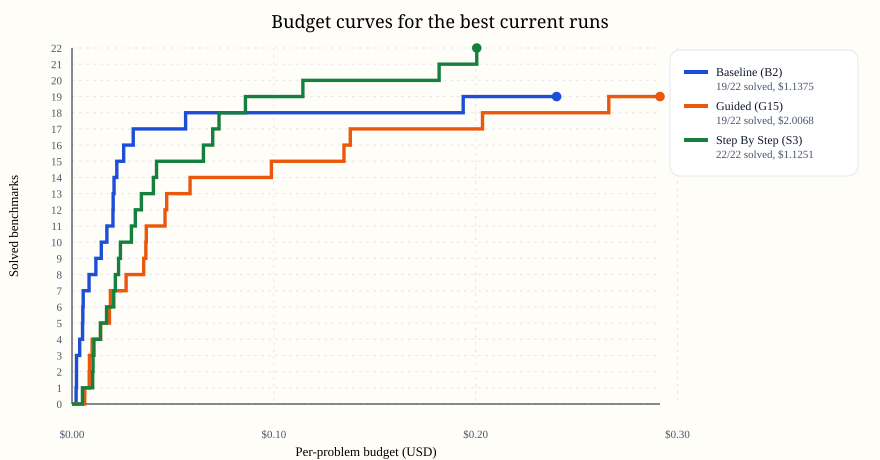

In [6]:
curves = ru.load_budget_curves(paths.report_root, [best_baseline_name, best_guided_name, best_step_name])
display(SVG(ru.render_budget_curves_svg(curves, inventory, title='Budget curves for the best current runs')))

The budget plot makes the three-way comparison easier to read.

- **Step-by-step reaches the top frontier**: it is the only current strategy that gets to **22 solved equations**.
- **It does so without a cost penalty**: the best step-by-step run ends at **$1.1251**, versus **$1.1375** for the best baseline run.
- **Guided remains the expensive option**: it matches baseline on solved count, but finishes about **$0.8693** higher.


## What Step-by-Step Adds

A small benchmark-level check is worth keeping because it explains *where* the full-coverage result comes from.

The best step-by-step run solves two equations that both best baseline and best guided miss. It does not give up any equation that either of the other two best runs solves. That means the step-by-step win is a genuine expansion of coverage, not just a different trade.


In [7]:
step_only = step_advantage.loc[step_advantage['status'] == 'step_only', ['bench_name', 'equation', 'baseline', 'guided', 'step_by_step']].copy()
step_only = step_only.rename(columns={
    'baseline': 'best baseline',
    'guided': 'best guided',
    'step_by_step': 'best step-by-step',
})
display(HTML(ru.render_simple_table_html(
    step_only,
    formatters={
        'best baseline': lambda value: 'yes' if value else 'no',
        'best guided': lambda value: 'yes' if value else 'no',
        'best step-by-step': lambda value: 'yes' if value else 'no',
    },
)))
print(f'Step regressions against the best baseline/guided runs: {int((step_advantage["status"] == "step_regression").sum())}')

bench_name,equation,best baseline,best guided,best step-by-step
018,cos(x + y)*cos(x - y) = cos(x)**2 - sin(y)**2,no,no,yes
019,sin(x + y)*sin(y - x) = cos(x)**2 - cos(y)**2,no,no,yes


Step regressions against the best baseline/guided runs: 0


## Common Failure Patterns by Model

The report artifacts do not record free-form error labels, so this section groups failures by the identity family of the missed benchmark. It is still useful because the patterns are sharp.

- `gpt-5.4` is narrow: its main weakness is **derived product identities**, with **18/22** failures (**81.8%**). Outside that family it mostly slips on **higher-order sine rewrites**.
- `gpt-5.4-mini` is much broader in its misses. It struggles most on **derived product identities** (**19/20**, **95.0%**), then on **higher-order sine rewrites**, and it still shows a substantial failure rate even on **periodicity**.
- `gpt-5.4-nano` looks closer to mini than to standard `gpt-5.4` in the kind of mistakes it makes, but it is more controlled. Its top two miss families are **derived product identities** and **higher-order sine rewrites**, and its third most common miss family is **periodicity**.

Taken together, the most persistent weak spot across all three models is not the basic angle-shift or product-sum material, but the more derived identities built from multiple transformations, especially benchmarks `018` and `019`.


In [8]:
BENCHMARK_GROUPS = {
    '001': 'phase shifts', '002': 'phase shifts', '003': 'phase shifts', '004': 'phase shifts',
    '005': 'special angles', '006': 'special angles', '007': 'special angles',
    '008': 'periodicity', '009': 'periodicity',
    '010': 'pythagorean',
    '011': 'double-angle / half-angle', '012': 'sum-product transforms', '013': 'sum-product transforms',
    '014': 'double-angle / half-angle', '015': 'double-angle / half-angle', '016': 'double-angle / half-angle', '017': 'double-angle / half-angle',
    '018': 'derived product identities', '019': 'derived product identities',
    '020': 'higher-order sine rewrites', '021': 'higher-order sine rewrites', '022': 'higher-order sine rewrites',
}

model_runs = runs.copy()
model_runs['analysis model'] = model_runs['model_name'].astype(str)
step_mask = model_runs['family'] == 'step_by_step'
model_runs.loc[step_mask, 'analysis model'] = model_runs.loc[step_mask, 'step_model_name'].astype(str)
model_runs['identity family'] = model_runs['bench_name'].map(BENCHMARK_GROUPS)
model_runs['failed'] = ~model_runs['success']
summary = (
    model_runs.groupby(['analysis model', 'identity family'], dropna=False)
    .agg(failures=('failed', 'sum'), total=('failed', 'size'))
    .reset_index()
)
summary['failure rate'] = summary['failures'] / summary['total']
summary = summary.sort_values(['analysis model', 'failure rate', 'failures', 'identity family'], ascending=[True, False, False, True])
ranked = summary.groupby('analysis model').head(3).copy()
ranked['family'] = ranked['identity family']
ranked['evidence'] = ranked.apply(lambda row: f"{int(row['failures'])}/{int(row['total'])} ({row['failure rate']:.1%})", axis=1)
ranked = ranked[['analysis model', 'family', 'evidence']].rename(columns={'analysis model': 'model'})
display(HTML(ru.render_simple_table_html(ranked)))

model,family,evidence
gpt-5.4,derived product identities,18/22 (81.8%)
gpt-5.4,higher-order sine rewrites,12/33 (36.4%)
gpt-5.4,double-angle / half-angle,4/55 (7.3%)
gpt-5.4-mini,derived product identities,19/20 (95.0%)
gpt-5.4-mini,higher-order sine rewrites,25/30 (83.3%)
gpt-5.4-mini,periodicity,12/20 (60.0%)
gpt-5.4-nano,derived product identities,18/20 (90.0%)
gpt-5.4-nano,higher-order sine rewrites,23/30 (76.7%)
gpt-5.4-nano,periodicity,6/20 (30.0%)


## Remaining Step-by-Step Cells

The current step-by-step evidence is already strong enough to include in the report, but the sweep is still incomplete. The missing runs below are the ones worth adding before making a firmer statement about reasoning-effort effects inside step-by-step itself.


In [9]:
missing_step = ru.build_step_missing_table(inventory)
missing_step = missing_step.loc[missing_step['status'] == 'missing'].copy()
display(HTML(ru.render_simple_table_html(missing_step)))

step model,step effort,status,runs
GPT-5.4,None,missing,—
GPT-5.4,medium,missing,—
GPT-5.4,high,missing,—
GPT-5.4 mini,high,missing,—
GPT-5.4 nano,high,missing,—
